## Rod Control Example

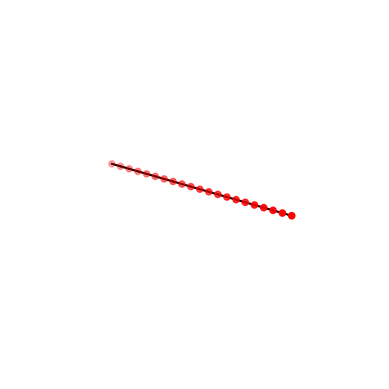

In [1]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=0.001,
                          shell_h=0)

material = dismech.Material(density=1200,
                            youngs_rod=2e6,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

dynamic_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=False,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-3,
                                  max_iter=25,
                                  total_time=1,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
env.add_force('rft', ct=0.01, cn=0.1)
# env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
# env.add_force('damping', eta=0.01)

geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/horizontal_rod_n21.txt')

robot = dismech.SoftRobot(geom, material, geo, dynamic_2d_sim, env)

In [2]:
stepper = dismech.ImplicitEulerTimeStepper(robot)

## Reference configuration from npz

In [3]:
# read reference configuration from npz file
ref_data = np.load('snake_kappa_ref.npz')
ref_kappa_traj=ref_data['kappa_traj'] 
ref_times = ref_data['ref_times']

print("reference trajectory of kappa:", ref_kappa_traj)
print("reference times:", ref_times)

print("shape of reference kappa traj:", ref_kappa_traj.shape)


reference trajectory of kappa: [[[ 0.         -0.        ]
  [ 0.         -0.        ]
  [ 0.         -0.        ]
  ...
  [ 0.         -0.        ]
  [ 0.         -0.        ]
  [ 0.         -0.        ]]

 [[ 0.          0.19560265]
  [ 0.          0.17610849]
  [ 0.          0.14114662]
  ...
  [ 0.          0.15048179]
  [ 0.          0.18104541]
  [ 0.          0.19452384]]

 [[ 0.          0.20471539]
  [ 0.          0.19607577]
  [ 0.          0.1668206 ]
  ...
  [ 0.          0.19198041]
  [ 0.          0.20923508]
  [ 0.          0.20341949]]

 ...

 [[ 0.          0.19852109]
  [ 0.          0.19531571]
  [ 0.          0.168596  ]
  ...
  [ 0.          0.13498605]
  [ 0.          0.17739677]
  [ 0.          0.19826681]]

 [[ 0.          0.19969671]
  [ 0.          0.19212293]
  [ 0.          0.16140621]
  ...
  [ 0.          0.14389707]
  [ 0.          0.1827726 ]
  [ 0.          0.19944727]]

 [[ 0.          0.20008408]
  [ 0.          0.18817152]
  [ 0.          0.15357875]

In [4]:
def upsample_kappa(ref_times, ref_values, dt_fine):
    """Linear time upsampling to a uniform fine grid."""
    t0, t1 = ref_times[0], ref_times[-1]
    Nfine = int(np.floor((t1 - t0)/dt_fine)) + 1
    tfine = t0 + np.arange(Nfine) * dt_fine      # (Nfine,)
    T, Nb, D = ref_values.shape
    out = np.empty((Nfine, Nb, D), dtype=float)

    # vectorized over bends by stacking np.interp results
    for d in range(D):  # d = 0,1 components
        # build (Nb, Nfine) then transpose to (Nfine, Nb)
        comp = np.vstack([
            np.interp(tfine, ref_times, ref_values[:, i, d])
            for i in range(Nb)
        ]).T
        out[:, :, d] = comp
    return tfine, out

tfine, ref_fine = upsample_kappa(ref_times, ref_kappa_traj, dt_fine=robot.sim_params.dt)  # (Nfine, Nb, 2)


In [5]:
print("tfine:", tfine)

tfine: [0.    0.001 0.002 ... 0.998 0.999 1.   ]


### Time Stepping
PID Control

In [6]:
from dismech.controllers.curvaturePITracker import CurvaturePITracker

# Y=1e6
Kp_kappa = 1
Ki_kappa = 0.5
Kd_kappa = 0.0

nat0 = robot.bend_springs.nat_strain.copy() 
tracker = CurvaturePITracker(
    nat0=nat0,
    # choose ONE of the two inputs below:
    # ref_func=ref_func, 
    ref_times=tfine, ref_values=ref_fine,   # (T,Nb,2)
    Kp=Kp_kappa, Ki=Ki_kappa, Kd=Kd_kappa, beta=1,
    du_rate_per_step=0.2,  # max rate of change of curvature per time step
    kappa_mag_max=np.inf, antiwindup_bc=0.9,
    smooth_alpha=0.01
)

dt = dynamic_2d_sim.dt
bend_energy = None
sat_flags = []

# Make a before_step callback that calls the controller each step
be = stepper.elastic_energies['bend']
dt = robot.sim_params.dt  # your dt

def actuate_track(robot, t):
    kappa_meas = be.get_strain(robot.state)                       # (Nb,2)
    nat = robot.bend_springs.nat_strain                           # (Nb,2), updated in-place
    nat_before = nat.copy()
    tracker.update(t, kappa_meas, nat, dt)                        # writes into nat
    sat_flags.append(np.linalg.norm(nat - nat_before) >= tracker.du_rate*0.99)  # rate sat proxy

    return robot


In [7]:
stepper.before_step = actuate_track
robots = stepper.simulate()


# stack initial q first with all other
qs0 = robot.state.q[np.newaxis, :]
robot0 = robot
qs_other = np.stack([robot.state.q for robot in robots])
qs = np.vstack([qs0, qs_other])

robots = [robot0] + robots # include the initial robot

t = np.linspace(0, dynamic_2d_sim.total_time, qs.shape[0])

iter: 1, error: 0.005
iter: 2, error: 0.004
current_time:  0.001
iter: 1, error: 0.006
iter: 2, error: 0.008
current_time:  0.002
iter: 1, error: 0.008
iter: 2, error: 0.013
current_time:  0.003
iter: 1, error: 0.011
iter: 2, error: 0.016
iter: 3, error: 0.000
current_time:  0.004
iter: 1, error: 0.014
iter: 2, error: 0.019
iter: 3, error: 0.000
current_time:  0.005
iter: 1, error: 0.016
iter: 2, error: 0.022
iter: 3, error: 0.000
current_time:  0.006
iter: 1, error: 0.018
iter: 2, error: 0.024
iter: 3, error: 0.000
current_time:  0.007
iter: 1, error: 0.020
iter: 2, error: 0.025
iter: 3, error: 0.000
current_time:  0.008
iter: 1, error: 0.020
iter: 2, error: 0.026
iter: 3, error: 0.000
current_time:  0.009000000000000001
iter: 1, error: 0.020
iter: 2, error: 0.026
iter: 3, error: 0.000
current_time:  0.01
iter: 1, error: 0.019
iter: 2, error: 0.012
iter: 3, error: 0.000
current_time:  0.011
iter: 1, error: 0.017
iter: 2, error: 0.006
current_time:  0.012
iter: 1, error: 0.014
iter: 2,

In [8]:
# t = np.arange(robot.sim_params.total_time, step=robot.sim_params.dt)
options = dismech.AnimationOptions(title='Rod PID', plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t, qs, options)
fig.show()

In [9]:
import numpy as np

# 1) Extract κ_ref(t) from the teacher rollout
def extract_kappa_traj_from_robots(robots, stepper):
    be = stepper.elastic_energies['bend']     # your BendEnergy
    kappas = []
    for rb in robots:
        # BendEnergy.get_strain expects RobotState
        kappa = be.get_strain(rb.state)       # shape (Nb,2)
        kappas.append(kappa.astype(np.float64))
    kappas = np.stack(kappas, axis=0)         # (T, Nb, 2)
    return kappas


kappa_traj = extract_kappa_traj_from_robots(robots, stepper)

if kappa_traj.shape != ref_fine.shape:
    raise ValueError("kappa_traj and ref_fine must have the same shape for error calculation.") 
err = kappa_traj - ref_fine

# find rmse error over time
bend_strain_errors = np.sqrt(np.mean(err**2, axis=(1,2)))
print("RMSE between extracted kappa_traj and ref_fine over time:", bend_strain_errors)

# mean error over time instead of rmse
bend_strain_errors_mean = np.mean(np.abs(err), axis=(1,2))
print("Mean absolute error between extracted kappa_traj and ref_fine over time:", bend_strain_errors_mean)


RMSE between extracted kappa_traj and ref_fine over time: [0.         0.00589046 0.00996011 ... 0.00035096 0.00034923 0.00034621]
Mean absolute error between extracted kappa_traj and ref_fine over time: [0.         0.00359658 0.00615809 ... 0.0002156  0.0002165  0.00021685]


In [10]:
print((bend_strain_errors.shape))

(1001,)


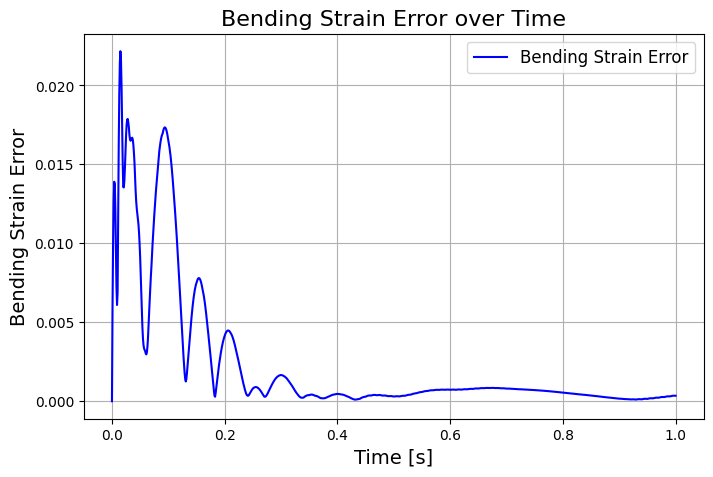

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# plot bending strain error over time
plt.figure(figsize=(8,5))
plt.plot(t[:], bend_strain_errors, label='Bending Strain Error', color='blue')
plt.xlabel('Time [s]', fontsize=14)
plt.ylabel('Bending Strain Error', fontsize=14)
plt.title('Bending Strain Error over Time', fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
# plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.show()

In [12]:
# calculate steady state error as average over last 10% of time
steady_state_start_index = int(0.9 * len(bend_strain_errors))
steady_state_error = np.mean(bend_strain_errors[steady_state_start_index:])
percentage_steady_state_error = (steady_state_error / np.max(ref_fine)) * 100
print("Steady state bending strain error (average over last 10% of time):", percentage_steady_state_error)

Steady state bending strain error (average over last 10% of time): 0.09327447242777227


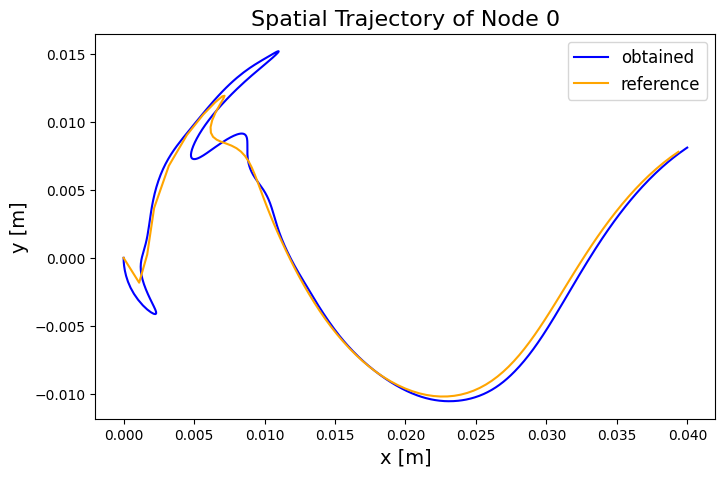

In [13]:
# plot spatial trajectories
ref_data_node0x = np.loadtxt('snake_node0_x_trajectory.txt')
ref_data_node0y = np.loadtxt('snake_node0_y_trajectory.txt')
plt.figure(figsize=(8,5))
plt.plot(qs[:, 0], qs[:,1], label='obtained', color='blue')
plt.plot(ref_data_node0x, ref_data_node0y, label='reference', color='orange')
plt.xlabel('x [m]', fontsize=14)
plt.ylabel('y [m]', fontsize=14)
plt.title('Spatial Trajectory of Node 0', fontsize=16)
# plt.grid(True)
plt.legend(fontsize=12)
plt.show()

In [14]:
sat_frac = np.mean(sat_flags)
print("Saturation fraction:", sat_frac)

Saturation fraction: 0.0


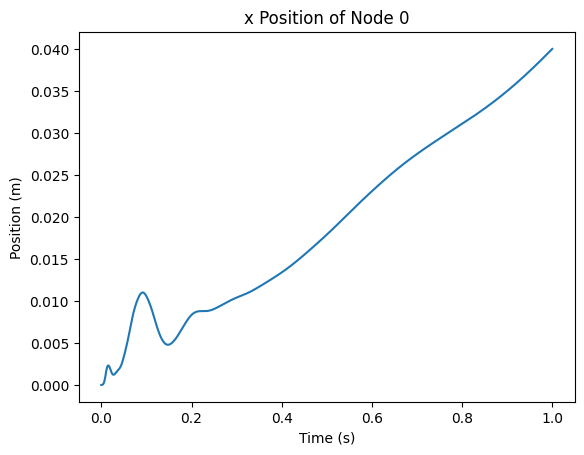

In [15]:
import matplotlib.pyplot as plt
plt.title("x Position of Node 0")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.plot(t, qs[:, 0])
plt.show()

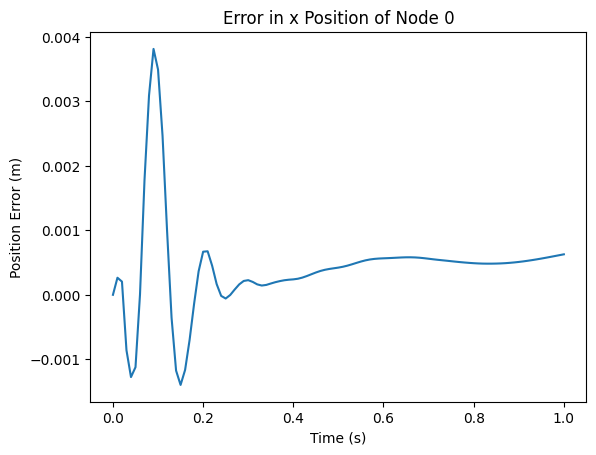

In [16]:
# error trajectory of node0 x coordinate
ref_data_node0 = np.loadtxt('snake_node0_x_trajectory.txt')
# error_node0 = qs[:, 0] - ref_data_node0
# use every 10th point from qs to match length of ref_data_node0
error_node0 = qs[::10, 0] - ref_data_node0
plt.title("Error in x Position of Node 0")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.plot(t[::10], error_node0)
plt.show()

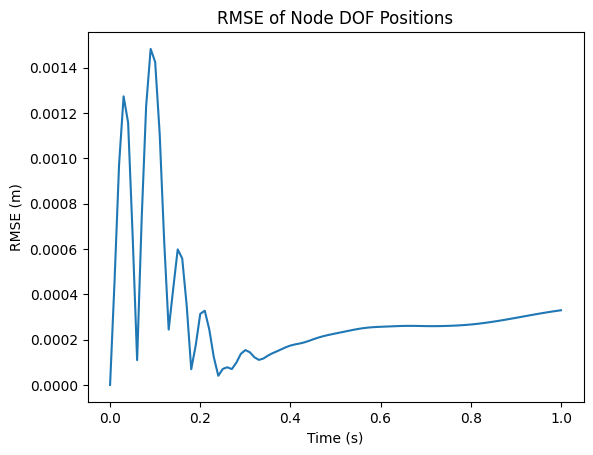

In [17]:
# plot position error RMSE for the node dofs
ref_data_node_all = np.load('snake_dof_trajectory.npz')
ref_dof_traj = ref_data_node_all['qs']  # shape (T, Ndof)
err_dof = qs[::10, 0:robot.end_node_dof_index] - ref_dof_traj
rmse_dof = np.sqrt(np.mean(err_dof**2, axis=1))
plt.title("RMSE of Node DOF Positions")
plt.xlabel("Time (s)")
plt.ylabel("RMSE (m)")
plt.plot(t[::10], rmse_dof)
plt.show()